# Nightlights in Border Crossing Locations

In [16]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt
from blackmarble import BlackMarble, Product, raster, extract
from pathlib import Path
from dotenv import dotenv_values

In [5]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "spatial-blackmarble-training").exists():
            return path
    return start


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "ntl_blackmarble" / "nigeria" / "raw" # change this to your directory
RAW_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
secrets_path = REPO_ROOT / ".config" / "ntl-training" / "secrets.env"
secrets = dotenv_values(secrets_path)
blackmarble_token = secrets.get("BLACKMARBLE_TOKEN", "").strip()

Read the border corssing file

In [6]:
border_crossings = pd.read_excel(DATA_DIR / "border_crossings" / "lac_border_crossings.xlsx")

Convert it into a geodataframe

In [8]:
border_crossings = gpd.GeoDataFrame(border_crossings, 
                                    geometry=gpd.points_from_xy(border_crossings["Longitude"], border_crossings["Latitude"]),
                                    crs="EPSG:4326")

Observe where they are

In [9]:
border_crossings.explore()

Create a buffer around these locations of 2km and 5km

In [ ]:
border_5km = border_crossings.copy()
border_5km['geometry'] = border_5km.to_crs(epsg=32637).buffer(5 * 1000).to_crs('EPSG:4326')

border_2km = border_crossings.copy()
border_2km['geometry'] = border_2km.to_crs(epsg=32637).buffer(2 * 1000).to_crs('EPSG:4326')

In [12]:
border_5km.explore()

In [14]:
border_2km.explore()

## Exercise

Write code to extract nightlights in the AOI we identified for the borders

In [ ]:
border_crossing_lights = extract.bm_extract(
    gdf = border_5km,
    product_id = Product.VNP46A3, # which product would you use? 
    aggfunc = [], # WHich aggregation works best for border crossings? Does it matter?
    date_range = pd.date_range('2026-01-01', '2026-05-31', freq='MS'),
    token = blackmarble_token
)

### Solution

In [18]:
border_crossing_lights = extract.bm_extract(
    gdf = border_5km,
    product_id = Product.VNP46A3,
    aggfunc = ['mean', 'sum'],
    date_range = pd.date_range('2026-01-01', '2026-05-31', freq='MS'),
    token = blackmarble_token
)

['h11v11']
['h11v11']
['https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2026001.h11v11.002.2026041164912.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2026060.h11v11.002.2026099182217.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2026032.h11v11.002.2026072184751.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2026091.h11v11.002.2026132234330.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2026121.h11v11.002.2026163132034.h5']


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


  0%|          | 0.00/64.8M [00:00<?, ?B/s]

  0%|          | 0.00/69.1M [00:00<?, ?B/s]

  0%|          | 0.00/70.2M [00:00<?, ?B/s]

  0%|          | 0.00/68.4M [00:00<?, ?B/s]

  0%|          | 0.00/67.8M [00:00<?, ?B/s]

COLLATING TILES | Processing...:   0%|          | 0/5 [00:00<?, ?date/s]

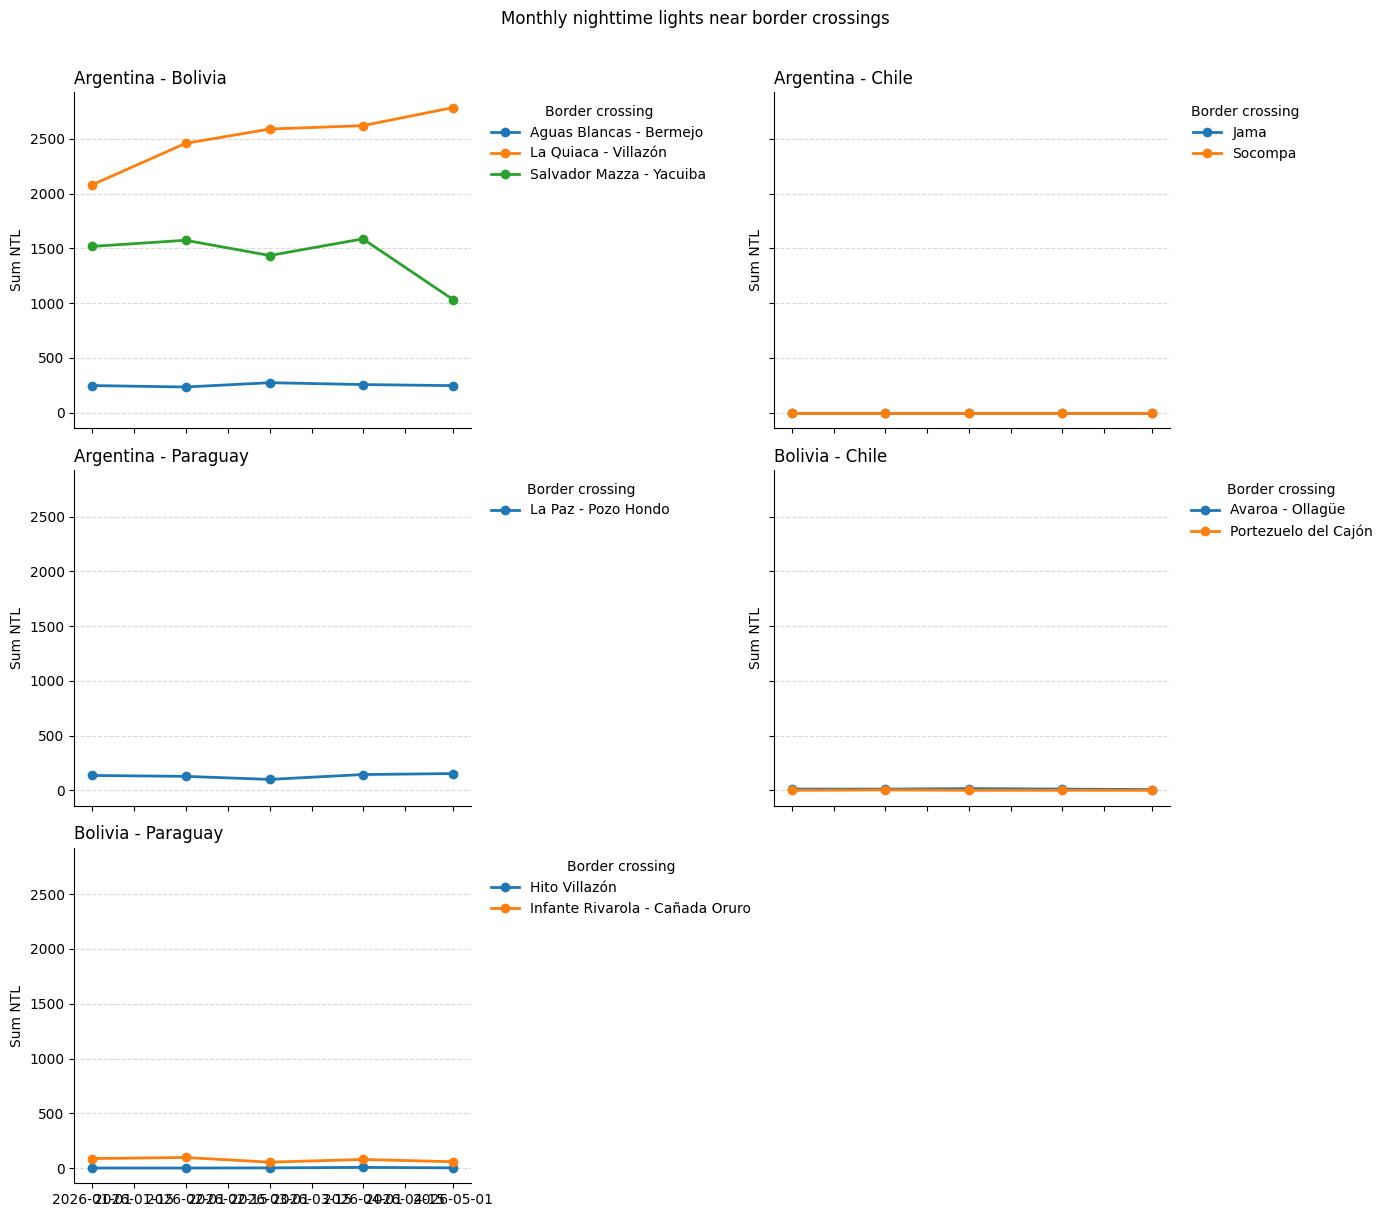

In [24]:
wbg_colors = [
    "#1F77B4",  # blue
    "#FF7F0E",  # orange
    "#2CA02C",  # green
    "#D62728",  # red
    "#9467BD",  # purple
    "#8C564B",  # brown
    "#E377C2",  # pink
    "#7F7F7F",  # grey
    "#BCBD22",  # olive
    "#17BECF",  # cyan
]

plot_df = border_crossing_lights.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

value_col = "ntl_sum"
borders = sorted(plot_df["Border"].dropna().unique())
ncols = 2
nrows = (len(borders) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

for ax, border in zip(axes, borders):
    border_df = plot_df[plot_df["Border"] == border]

    for i, (name, group) in enumerate(border_df.groupby("Name")):
        group = group.sort_values("date")
        ax.plot(
            group["date"],
            group[value_col],
            marker="o",
            linewidth=2,
            color=wbg_colors[i % len(wbg_colors)],
            label=name,
        )

    ax.set_title(border, loc="left")
    ax.set_xlabel(None)
    ax.set_ylabel("Mean NTL" if value_col == "ntl_mean" else "Sum NTL")
    ax.grid(axis="y", color="#D9D9D9", linestyle="--", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(title="Border crossing", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

for ax in axes[len(borders):]:
    ax.set_visible(False)

fig.suptitle("Monthly nighttime lights near border crossings", y=1.01)
plt.tight_layout()
plt.show()

In [25]:
border_crossing_lights.to_csv(DATA_DIR / "border_crossing_lights.csv", index=False)